# 8장 실습 — 환경을 몇 개나 돌릴 것인가

여기서부터 정책이 바뀐다. 3장부터 7장까지 정책은 손으로 쓴 규칙이었고, 손잡이가 많아야 네 개였다. 이제 신경망이 그 자리에 들어오고 PPO가 그것을 학습시킨다.

바뀌는 것이 하나 더 있다. 시뮬레이터가 **여러 벌** 돈다. 강화학습은 표본을 먹는 기계이고, 로봇 시뮬에서 그 표본을 만드는 유일한 방법이 병렬화다. 그래서 이 장의 질문은 실무에서 가장 먼저 마주치는 질문이 된다 — **몇 개를 돌릴 것인가.**

흔한 답은 「GPU가 감당하는 만큼」이다. 이 노트북은 그 답이 왜 절반만 맞는지를 잰다. 환경 수를 바꾸는 것은 계산 자원을 바꾸는 일이 아니라 **학습 알고리즘의 설정을 통째로 바꾸는 일**이기 때문이다.

실행 시간은 CPU에서 6분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


## 벡터 환경을 세운다

과제는 앞 장들과 같은 평면 밀기다. 달라지는 것은 껍데기다. 환경 하나가 아니라 n개를 한 덩어리로 묶고, 관측과 보상을 n행짜리 배열로 내놓는다. 에피소드가 끝난 환경은 혼자 알아서 초기화한다.

보상은 조밀하게 준다. 블록이 목표에 가까워진 만큼, 밀대가 블록에 가까워진 만큼 준다. 뒤쪽 항이 없으면 학습 초반에 블록을 건드리는 일 자체가 우연에 맡겨진다. 보상 설계 이야기는 9장에서 본격적으로 한다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="{kv}"/>
    <velocity joint="py" kv="{kv}"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MU, KV = .60, 120.


class Vec:
    # 환경 n 개를 한 덩어리로 다룬다
    def __init__(self, n, seed=0, mu=MU, kv=KV, lat=0, noise=0.):
        self.m = mujoco.MjModel.from_xml_string(
            XML.format(mu=mu, kv=kv))
        self.sub = int(round(1 / 20 / self.m.opt.timestep))
        self.n, self.lat, self.noise = n, lat, noise
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
        self.buf[i] = [np.zeros(2)] * (self.lat + 1)

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2])
            if self.noise:
                b = b + self.rng.normal(0, self.noise, 2)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)      # 스케일을 1 근처로

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        done = np.zeros(self.n, np.float32)
        succ = []
        for i, d in enumerate(self.d):
            self.buf[i].append(np.clip(a[i], -1, 1) * AMAX)
            d.ctrl[:] = self.buf[i][-1 - self.lat]
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = 10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
            if db < GOAL_R:
                r[i] += .3
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                done[i] = 1.
                succ.append(float(db < GOAL_R))
                self.reset(i)
        return self.obs(), r, done, succ

## 정책과 PPO

정책은 은닉 64짜리 두 층 MLP다. 가치 함수도 같은 모양으로 따로 둔다. 행동은 대각 가우시안이고 표준편차는 상태와 무관한 학습 파라미터다 — 로코모션 연구들이 널리 쓰는 가장 단순한 구성이다.

PPO 구현은 교과서 그대로다. 클립 비율 0.2, GAE(λ=0.95), γ=0.99, 에폭 4회. 이 노트북에서 바꿔 가며 볼 것은 알고리즘이 아니라 **n(환경 수)과 T(한 번 모으는 길이)** 둘뿐이다.

한 번의 갱신에 쓰이는 표본 수는 n × T이고, 전체 예산이 정해져 있으면 갱신 횟수는 예산 ÷ (n × T)가 된다. 이 세 수가 서로 묶여 있다는 것이 이 노트북의 전부다.

In [4]:
class AC(nn.Module):
    def __init__(self):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(8, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(8, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train(n, T, budget, seed=0, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps, hist, won = 0, [], []
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):                      # 표본을 모은다
            ot = torch.from_numpy(o)
            with torch.no_grad():
                dist = ac.dist(ot)
                a = dist.sample()
                LP[t] = dist.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            o, R[t], D[t], sc = env.step(A[t])
            won += sc
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n

        adv = np.zeros((T, n), np.float32)      # GAE
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        ret = adv + V[:T]

        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(ret.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):                      # 갱신
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                dist = ac.dist(bo[j])
                lp = dist.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * dist.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
        if won:
            hist.append((steps, float(np.mean(won[-200:]))))
    return ac, hist

## 먼저 처리량을 잰다

학습 이야기를 하기 전에 순수한 계산 이야기부터 한다. 환경 수를 1에서 256까지 늘려 가며 **초당 환경 스텝 수**를 재고, 그 시간이 어디에 쓰이는지 나눠 본다.

In [5]:
def throughput(n, total=12000, rep=2):
    # 공유 CPU 에서는 시간이 튄다. 두 번 재서 좋은 쪽을 쓴다
    env, ac = Vec(n, 0), AC()
    T = max(1, total // n)
    best = None
    for _ in range(rep):
        tp = tn = 0.
        t0 = time.perf_counter()
        for _ in range(T):
            a = time.perf_counter()
            with torch.no_grad():
                u = ac.pi(torch.from_numpy(env.obs())).numpy()
            b = time.perf_counter()
            env.step(u)
            c = time.perf_counter()
            tn += b - a
            tp += c - b
        el = time.perf_counter() - t0
        if best is None or T * n / el > best[0]:
            best = (T * n / el, tp / el, tn / el)
    return best


NS = [1, 2, 4, 8, 16, 32, 64, 128, 256]
tho = [throughput(n) for n in NS]

print(pad("환경 수", 10) + pad("환경 스텝/초", 16, True)
      + pad("물리", 10, True) + pad("신경망", 10, True))
for n, (s, fp, fn) in zip(NS, tho):
    print(pad(n, 10) + pad(f"{s:,.0f}", 16, True)
          + pad(f"{fp:.0%}", 10, True) + pad(f"{fn:.0%}", 10, True))

환경 수       환경 스텝/초      물리    신경망
1                    6,676       71%       29%
2                    9,162       77%       23%
4                   10,944       84%       16%
8                   11,585       87%       12%
16                  11,536       89%       11%
32                  11,547       91%        9%
64                  11,968       92%        8%
128                 10,965       92%        8%
256                 11,269       94%        6%


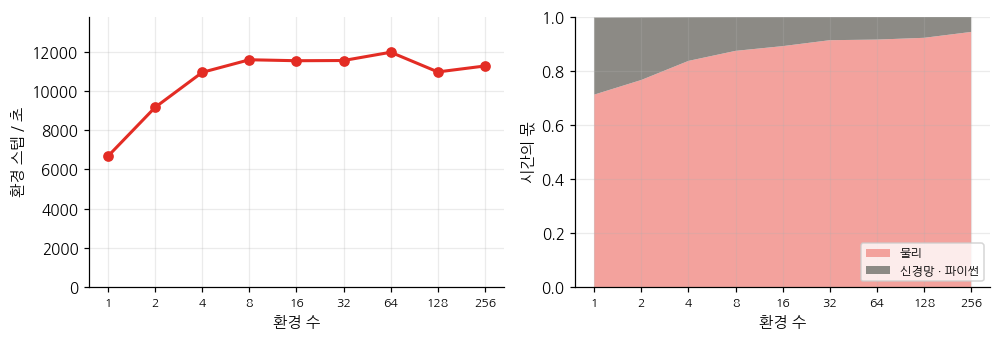

In [6]:
sp = [x[0] for x in tho]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.2, 3.2))
a1.plot(range(len(NS)), sp, "o-", color=RED, lw=2)
a1.set_xticks(range(len(NS)))
a1.set_xticklabels(NS, fontsize=8)
a1.set_xlabel("환경 수")
a1.set_ylabel("환경 스텝 / 초")
a1.set_ylim(0, max(sp) * 1.15)
a2.stackplot(range(len(NS)), [x[1] for x in tho],
             [x[2] for x in tho], colors=(PINK, GREY),
             labels=("물리", "신경망 · 파이썬"))
a2.set_xticks(range(len(NS)))
a2.set_xticklabels(NS, fontsize=8)
a2.set_xlabel("환경 수")
a2.set_ylabel("시간의 몫")
a2.set_ylim(0, 1)
a2.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 고정 예산에서 환경 수를 바꾼다

이제 학습이다. 전체 환경 스텝 예산을 12만으로 고정하고, T = 32를 고정한 채 환경 수만 바꾼다. **하이퍼파라미터는 전부 그대로 둔다.** 실무에서 환경 수를 늘릴 때 흔히 하는 일이 그것이기 때문이다.

In [7]:
BUDGET, POL = 120_000, {}
rows = []
t0 = time.time()
for n in (4, 16, 64, 256):
    a = time.time()
    ac, h = train(n, 32, BUDGET, seed=0)
    POL[f"n={n}"] = ac
    rows.append((n, 32, n * 32, BUDGET // (n * 32), h[-1][1],
                 time.time() - a))
    print(f"n = {n:<4} 끝  ({time.time()-t0:.0f}s)")

print()
print(pad("환경 수", 9) + pad("배치", 9, True)
      + pad("갱신 횟수", 12, True) + pad("성공률", 10, True)
      + pad("벽시계", 10, True))
for n, T, b, u, s, sec in rows:
    print(pad(n, 9) + pad(b, 9, True) + pad(u, 12, True)
          + pad(f"{s:.2f}", 10, True)
          + pad(f"{sec:.0f}s", 10, True))

n = 4    끝  (36s)


n = 16   끝  (60s)


n = 64   끝  (77s)


n = 256  끝  (91s)

환경 수       배치   갱신 횟수    성공률    벽시계
4              128         937      0.03       36s
16             512         234      0.60       24s
64            2048          58      0.73       17s
256           8192          14      0.04       14s


## 왼쪽 절반은 하이퍼파라미터 탓이다

환경 수를 4로 줄이면 한 번 갱신에 쓰는 표본이 128개뿐이다. 그 작은 표본으로 잰 그래디언트는 시끄럽고, 시끄러운 그래디언트에 학습률 3e-3은 너무 크다. **환경 수를 바꾼 것이 사실은 유효 배치 크기를 바꾼 것**이었고, 배치를 바꿨으면 학습률도 같이 바꿨어야 했다.

학습률만 내려서 같은 실험을 다시 돌려 본다.

In [8]:
a = time.time()
ac4, h4 = train(4, 32, BUDGET, seed=0, lr=5e-4)
POL["n=4 (lr 조정)"] = ac4
print(f"n = 4, 학습률 5e-4 → 성공률 {h4[-1][1]:.2f}"
      f"  ({time.time()-a:.0f}s)")
print(f"같은 n, 학습률 3e-3 → 성공률 {rows[0][4]:.2f}")

n = 4, 학습률 5e-4 → 성공률 0.82  (38s)
같은 n, 학습률 3e-3 → 성공률 0.03


## 오른쪽 절반은 진짜다

그럼 환경 수 256이 무너진 것도 학습률 탓인가. 아니다. 갱신을 열네 번밖에 못 했다는 사실은 학습률로 살 수 없다.

환경 수를 늘리면서 갱신 횟수를 지키려면 T를 줄이는 수밖에 없다. Rudin과 동료들이 4,000대를 돌리면서 호라이즌을 24스텝으로 잡은 것이 그 선택이다. 그런데 T를 줄이는 데도 바닥이 있다. **배치 크기 n × T를 1,024로 고정한 채** T만 바꿔 본다.

In [9]:
rows2 = []
t0 = time.time()
for n, T in ((8, 128), (32, 32), (128, 8)):
    a = time.time()
    ac, h = train(n, T, BUDGET, seed=0)
    POL[f"T={T}"] = ac
    rows2.append((n, T, h[-1][1], time.time() - a))
    print(f"n = {n:<4} T = {T:<4} 끝  ({time.time()-t0:.0f}s)")

print()
print(pad("환경 수", 9) + pad("호라이즌 T", 12, True)
      + pad("배치", 9, True) + pad("갱신 횟수", 12, True)
      + pad("성공률", 10, True))
for n, T, s, sec in rows2:
    print(pad(n, 9) + pad(T, 12, True) + pad(n * T, 9, True)
          + pad(BUDGET // (n * T), 12, True)
          + pad(f"{s:.2f}", 10, True))

n = 8    T = 128  끝  (21s)


n = 32   T = 32   끝  (39s)


n = 128  T = 8    끝  (56s)

환경 수    호라이즌 T     배치   갱신 횟수    성공률
8                 128     1024         117      0.96
32                 32     1024         117      0.93
128                 8     1024         117      0.08


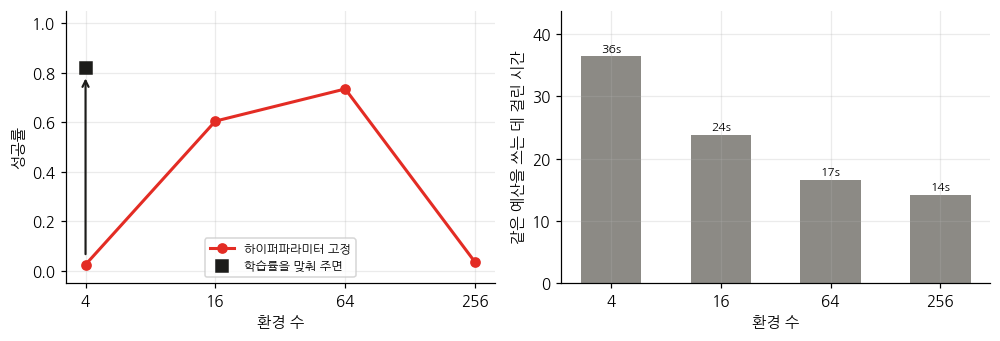

In [10]:
ns = [r[0] for r in rows]
sc = [r[4] for r in rows]
wc = [r[5] for r in rows]
x = np.arange(len(ns))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.2, 3.2))
a1.plot(x, sc, "o-", color=RED, lw=2, ms=6,
        label="하이퍼파라미터 고정")
a1.plot([0], [h4[-1][1]], "s", color=INK, ms=8,
        label="학습률을 맞춰 주면")
a1.annotate("", xy=(0, h4[-1][1] - .03), xytext=(0, sc[0] + .03),
            arrowprops=dict(arrowstyle="->", color=INK, lw=1.4))
a1.set_xticks(x)
a1.set_xticklabels(ns)
a1.set_xlabel("환경 수")
a1.set_ylabel("성공률")
a1.set_ylim(-.05, 1.05)
a1.legend(fontsize=8, loc="lower center")

a2.bar(x, wc, color=GREY, width=.55)
for i, v in enumerate(wc):
    a2.text(i, v + .6, f"{v:.0f}s", ha="center", fontsize=8)
a2.set_xticks(x)
a2.set_xticklabels(ns)
a2.set_xlabel("환경 수")
a2.set_ylabel("같은 예산을 쓰는 데 걸린 시간")
a2.set_ylim(0, max(wc) * 1.2)
plt.tight_layout()
plt.show()

## 학습된 정책을 3장의 자로 채점한다

마지막으로 이 책의 물음을 다시 던진다. 여기서 만든 정책들을 학습에 쓴 시뮬에서 채점한 순위가, 실기에서의 순위와 맞는가.

실기는 앞 장들과 같은 방식으로 세운다 — 마찰 0.75, 게인 90, 지연 2스텝, 관측 잡음 4 mm. 학습은 이 값을 한 번도 보지 않았다.

In [11]:
def evaluate(ac, n=150, real=False, mean_only=False):
    # 학습할 때와 같게, 정책 분포에서 표집해 굴린다
    kw = dict(mu=.75, kv=90., lat=2, noise=.004) if real else {}
    env = Vec(8, 999, **kw)
    got = []
    while len(got) < n:
        o = torch.from_numpy(env.obs())
        with torch.no_grad():
            u = ac.pi(o).numpy() if mean_only \
                else ac.dist(o).sample().numpy()
        got += env.step(u)[3]
    return float(np.mean(got[:n]))


def mmrv(pred, real):
    pred, real = np.asarray(pred), np.asarray(real)
    out = []
    for i in range(len(pred)):
        v = [abs(real[i] - real[j])
             for j in range(len(pred))
             if (pred[i] - pred[j]) * (real[i] - real[j]) < 0]
        out.append(max(v) if v else 0.)
    return float(np.mean(out))


names = list(POL)
sim = [evaluate(POL[k]) for k in names]
rea = [evaluate(POL[k], real=True) for k in names]

print(pad("정책", 16) + pad("학습 시뮬", 12, True)
      + pad("실기", 10, True) + pad("떨어진 폭", 12, True))
for k, s, r in zip(names, sim, rea):
    print(pad(k, 16) + pad(f"{s:.2f}", 12, True)
          + pad(f"{r:.2f}", 10, True)
          + pad(f"{r-s:+.2f}", 12, True))
print()
print(f"MMRV {mmrv(sim, rea):.3f}"
      f"  /  Pearson r {np.corrcoef(sim, rea)[0, 1]:.3f}")

정책               학습 시뮬      실기   떨어진 폭
n=4                     0.04      0.00       -0.04
n=16                    0.84      0.26       -0.58
n=64                    0.83      0.05       -0.77
n=256                   0.03      0.03       +0.01
n=4 (lr 조정)           0.59      0.04       -0.55
T=128                   0.98      0.01       -0.97
T=32                    0.95      0.19       -0.77
T=8                     0.11      0.01       -0.09

MMRV 0.103  /  Pearson r 0.542


## 정리

**처리량은 오르다 멈춘다.** 환경이 적을 때 시간의 3분의 1을 먹는 것은 물리가 아니라 파이썬과 신경망 호출이다. 환경을 늘리면 그 몫이 나뉘어 사라지고, 다 사라지고 나면 물리만 남아 처리량이 평평해진다. 포화점의 위치는 하드웨어가 정한다 — 이 CPU에서는 열 개 언저리, RTX A6000에서는 로봇 4,000대 언저리다.

**관측이 이미지가 되면 이 계산이 다시 쓰인다.** 같은 GPU에서 상태 관측 4,096 환경이 6.1 GB일 때 RGB 카메라를 켠 1,024 환경이 16.7 GB다.

**환경 수를 바꾸는 것은 학습 설정을 바꾸는 것이다.** 하이퍼파라미터를 고정한 채 환경 수만 훑으면 뒤집힌 U자가 나오는데, 그 왼쪽 절반은 학습률 한 줄로 사라졌다. 성공률 0.03이 0.82가 됐다.

**오른쪽 절반은 사라지지 않는다.** 환경을 늘리면 갱신 횟수가 마르고, 그것을 막으려 호라이즌을 줄이면 이번에는 GAE가 볼 수 있는 미래가 짧아진다. 배치와 갱신 횟수를 똑같이 맞춰도 T = 8에서 학습이 끊겼다.

**환경 수가 사는 것은 표본 효율이 아니라 벽시계 시간이다.** 이것이 병렬 시뮬레이터가 로봇 RL을 바꾼 방식이고, 다음 세 장의 전제이기도 하다.

다음 장은 이 파이프라인에 보상을 다시 들여다본다. 여기서는 보상을 손으로 적당히 만들어 넣었는데, 그 「적당히」가 어디까지 통하는지가 9장의 주제다.